# Importing Libraries

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import sqlite3


In [2]:
conn = sqlite3.connect('customer_churn.db')
sql_query = '''
            SELECT name
            FROM sqlite_master
            WHERE type = 'table'
'''
tables = pd.read_sql(sql_query,conn)

for table_name in tables['name']: 
    df = pd.read_sql(f" SELECT * FROM {table_name}",conn) 
    globals()[f"df_{table_name}"] = df
    print(f"Created Dataframe: df_{table_name}")

conn.close()


Created Dataframe: df_db_customer
Created Dataframe: df_db_subscription
Created Dataframe: df_db_support


In [3]:
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']: 
    print(f"\nTable Name: {table_name}")
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query,conn)
    print("Columns:")
    print(columns['name'].tolist())

conn.close()




Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


# EDA

In [4]:
# top 5 rows 
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [227]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [228]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [229]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


# Data Cleaning 

# 1.) Customer

In [5]:
df_db_customer.rename(columns = {'cust_name' : 'customer_name'} , inplace = True)
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [6]:
#df_db_customer.drop(df_db_customer.columns[-2:] , axis = 1) # for row - axis = 0
df_db_customer.drop(columns=['interests','pincode'])


,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [232]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [7]:
df_db_customer['gender'].replace({'Men' : 'Male','Women' : 'Female'})

0       Male
1       Male
2     Female
3       Male
4     Female
5     Female
6     Female
7       Male
8     Female
9       Male
10      Male
11    Female
12    Female
13    Female
14      Male
15    Female
16    Female
17    Female
18      Male
19      Male
20    Female
Name: gender, dtype: object

In [8]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [9]:
df_db_customer['country'].isna()

0     False
1     False
2     False
3     False
4     False
5      True
6     False
7     False
8      True
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
Name: country, dtype: bool

In [10]:
#df_db_customer['country'].isna()
df_db_customer[df_db_customer['country'].isna()]

,customerid,name,country,state,gender,dob,interests,pincode
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01 00:00:00,None,None


In [11]:
state_country_mapping = df_db_customer.dropna(subset= ['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [12]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,name,country,state,gender,dob,interests,pincode


# 2.) Subscription 

In [13]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [14]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [15]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


# 3.) Support

In [20]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [16]:
df_db_support.drop(columns = ['col_1','comment'],inplace = True)

In [17]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


# Feature Engineering and Data Analysis.

In [18]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [19]:
df_db_subscription.head() # for 1 - it means user left. 

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [24]:
print(type(df_db_support))

<class 'pandas.core.frame.DataFrame'>


In [20]:
print(df_db_subscription['customerid'].dtype)
print(df_db_customer['customerid'].dtype)
print(df_db_support['customerid'].dtype)

object
object
object


In [21]:
df_db_customer = df_db_customer.rename(
    columns={'name': 'customer_name'}
)

df_db_customer = df_db_customer.drop(
    columns=['interests', 'pincode']
)

# Merging..

In [22]:
(df_db_subscription.merge(df_db_customer, on = 'customerid', how = 'left')
                   .merge(df_db_support,  on = 'customerid', how = 'left'))

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23 00:00:00,2024-08-28 00:00:00,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23 00:00:00,2024-08-28 00:00:00,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15 00:00:00,NaN,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05 00:00:00,2024-01-20 00:00:00,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0,durga,India,Delhi,Women,1988-12-10 00:00:00,2025-03-18 00:00:00,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21 00:00:00,2024-11-01 00:00:00,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0,maya,Nepal,Kathmandu,Women,1985-07-07 00:00:00,NaN,NaN,NaN


In [23]:
# Having duplicate problem. 
df_db_subscription.shape

(21, 12)

In [24]:
df_db_subscription['customerid'].nunique()
#df_db_subscription['customerid'].size

21

In [25]:
df_db_support['customerid'].nunique()
#df_db_support['customerid'].size # problem 

7

In [26]:
df_db_support['customerid'].size

9

In [27]:
df_db_customer['customerid'].nunique()

21

In [28]:
####### check the duplicate in support 
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30


In [29]:
# Group by 
df_db_support.groupby('customerid')['customerid'].transform('count')

0    2
1    2
2    1
3    1
4    1
5    1
6    1
7    2
8    2
Name: customerid, dtype: int64

In [30]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [31]:
df_db_support # col - column_count column created 


,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28 00:00:00,N,60,2
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,2
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,1
3,0013-MHZWF,2025-03-18 00:00:00,N,90,1
4,0013-SMEOE,2024-11-01 00:00:00,N,30,1
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,1
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,1
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,2
8,0022-TCJCI,2024-09-14 00:00:00,N,90,2


In [32]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [33]:
df_db_support['customerid'].size

7

In [34]:
# merge check 
df = (df_db_subscription
      .merge(df_db_customer, on = 'customerid', how = 'left')
      .merge(df_db_support,  on = 'customerid', how = 'left'))

In [35]:
df.shape

(21, 21)

In [36]:
# exporting the df 
df.to_csv('exported_churn_data.csv',index = False)

# Data Analysis (KPI)

In [37]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [38]:
df['churn_flag'].mean()

np.float64(0.2857142857142857)

In [39]:
churn_rate = df['churn_flag'].mean()*100
print("Churn rate = ", round(churn_rate,2), "%")

Churn rate =  28.57 %


In [40]:
retention_rate = 100 - churn_rate
print("Retention Rate =",round(retention_rate,2),"%")

Retention Rate = 71.43 %


In [41]:
df.groupby('plan_type')['churn_flag'].mean()

plan_type
Basic       0.600000
Premium     0.142857
Standard    0.222222
Name: churn_flag, dtype: float64

In [42]:
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [43]:
churn_by_state = (df.groupby('state')
                  .agg(churn_rate_pct=('churn_flag', lambda x: x.mean() * 100),
                       total_revenue=('monthly_charges', 'sum'),
                       user_count=('customerid', 'nunique')).round(2).reset_index())

print(churn_by_state)

           state  churn_rate_pct  total_revenue  user_count
0          Delhi           25.00          52.96           4
1      Karnataka          100.00          20.98           2
2      Kathmandu            0.00          20.98           2
3    Maharashtra            0.00          50.97           3
4      Meghalaya           66.67          42.97           3
5       Nagaland            0.00          22.99           1
6      Rajasthan            0.00          36.98           2
7      Telangana           50.00          30.98           2
8  Uttar Pradesh            0.00         115.98           2


In [44]:
churn_by_subscription = (
    df.groupby('subscription_type')
      .agg(
          churn_rate_pct=('churn_flag', lambda x: x.mean() * 100),
          total_revenue=('monthly_charges', 'sum'),
          user_count=('customerid', 'nunique')
      )
      .round(2)
      .reset_index()
)

print(churn_by_subscription)

  subscription_type  churn_rate_pct  total_revenue  user_count
0           Organic            0.00         145.91           9
1              Paid           16.67         174.94           6
2          Refferal           83.33          74.94           6


In [45]:
arpu = df['monthly_charges'].mean()
print('ARPU =',round(arpu,2))

ARPU = 18.85


In [46]:
# Average Customer Tenure 
# count of days has used our services. 
pd.Timestamp.today()

Timestamp('2026-08-19 03:45:32.749590')

In [47]:
today = pd.Timestamp.today() 
df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date']-df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)
avg_tenure = df['tenure_days'].mean()
print(" Avg Tenure (days)= ",round(avg_tenure))

 Avg Tenure (days)=  1520


In [48]:
revenue_at_risk = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue at risk =",revenue_at_risk,"K")

Revenue at risk = 73.94 K


In [49]:
esclation_rate = (df['escalations']== 'Y').mean()*100
print("eslation rate = ",round(esclation_rate,2),"%")

eslation rate =  19.05 %


In [50]:
avg_complaints = df['complaint_count'].sum()/df['customerid'].nunique()
print(" Avg Complaints per user = ", round(avg_complaints,2))

 Avg Complaints per user =  0.43


# Encoding

In [51]:
df['escalations'] = df['escalations'].map({'Y': 1, 'N': 0})

In [52]:
df['escalations'] = np.where(df['escalations']=='Y',1,0) # encoding string to int type 

In [53]:
print(df['escalations'].value_counts(dropna=False))

escalations
0    21
Name: count, dtype: int64


In [54]:
print(df['churn_flag'].value_counts(dropna=False))

churn_flag
0    15
1     6
Name: count, dtype: int64


In [55]:
print(df['escalations'].value_counts(dropna=False))
print(df['escalations'].dtype)

print(df['churn_flag'].value_counts(dropna=False))
print(df['churn_flag'].dtype)

escalations
0    21
Name: count, dtype: int64
int64
churn_flag
0    15
1     6
Name: count, dtype: int64
int64


In [56]:
print(df_db_support['escalations'].value_counts(dropna=False))

escalations
Y    4
N    3
Name: count, dtype: int64


In [57]:
df = (
    df_db_subscription
    .merge(df_db_customer, on='customerid', how='left')
    .merge(df_db_support, on='customerid', how='left')
)

In [58]:
df['escalations'] = (
    df['escalations']
    .astype('string')
    .str.strip()
    .str.upper()
    .map({'Y': 1, 'N': 0})
)

In [59]:
print(df['escalations'].value_counts(dropna=False))

escalations
NaN    14
1.0     4
0.0     3
Name: count, dtype: int64


In [60]:
df['escalations'] = df['escalations'].fillna(0)

In [61]:
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(
    corr_df['churn_flag']
)

print("Correlation between escalations vs churn =", round(correlation, 2))

Correlation between escalations vs churn = 0.77


In [62]:
# Churn risk - create a column using existing col
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
    
]
choices = ['low','med','high']
df['churn_risk'] = np.select(conditions,choices,default='unkown')

In [63]:
df[['churn_risk','churn_score']].tail()

,churn_risk,churn_score
16,med,62
17,low,27
18,high,99
19,low,7
20,low,47


# Visualization Using MATPLOTLIB

In [64]:
df_visual = df.copy()

In [65]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk'],
      dtype='object')

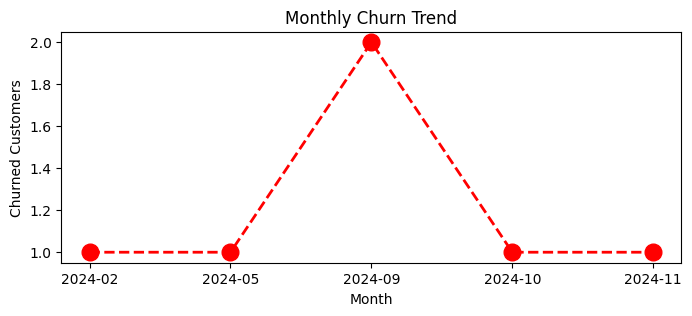

In [66]:
df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn_flag']== 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color = 'red',marker = 'o',linestyle = 'dashed',linewidth=2, markersize = 12)

plt.title("Monthly Churn Trend")
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

In [ ]:
#.

<BarContainer object of 3 artists>

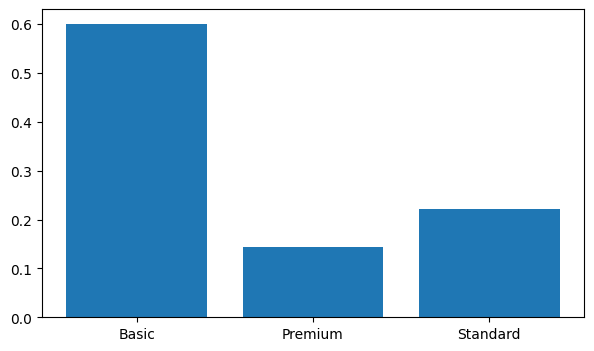

In [48]:
 churn_plan =df_visual.groupby('plan_type')['churn_flag'].mean()

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values)

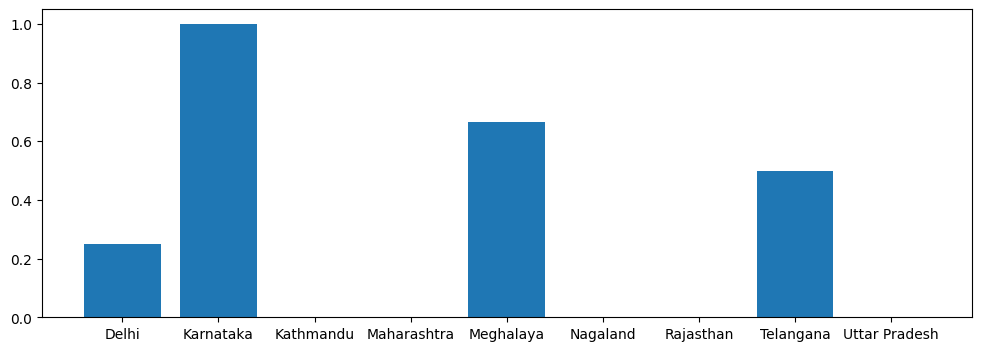

In [49]:
churn_plan =df_visual.groupby('state')['churn_flag'].mean()

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values)
plt.show()

# Visualization by Seaborn

In [63]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk'],
      dtype='object')

In [80]:
df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag','churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0.0
1,Premium,Annual,91,1,high,1.0
2,Basic,Monthly,34,0,low,0.0
3,Premium,Annual,8,0,low,0.0
4,Standard,Monthly,88,1,high,1.0


In [69]:
import warnings
warnings.filterwarnings('ignore')

In [81]:
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag','churn_risk', 'escalations']]
categorial_cols = ['plan_type','contract_type','churn_risk']

for col in categorial_cols: 
    df_encoded[col] = df_encoded[col].astype('category').cat.codes 

In [82]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0.0
1,1,0,91,1,0,1.0
2,0,1,34,0,1,0.0
3,1,0,8,0,1,0.0
4,2,1,88,1,0,1.0


In [86]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'med'], dtype=object)

In [87]:
# Correct method of encoding - based on priority 

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag','churn_risk', 'escalations']]

order_mappings = {
    'plan_type':['Basic','Standard','Premium'],
    'contract_type': ['Monthly','Annual'], 
    'churn_risk': ['low','med','high']
}

for col, order in order_mappings.items(): 
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes

In [88]:
 df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag','churn_risk', 'escalations']].head()


,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0.0
1,Premium,Annual,91,1,high,1.0
2,Basic,Monthly,34,0,low,0.0
3,Premium,Annual,8,0,low,0.0
4,Standard,Monthly,88,1,high,1.0


<Axes: >

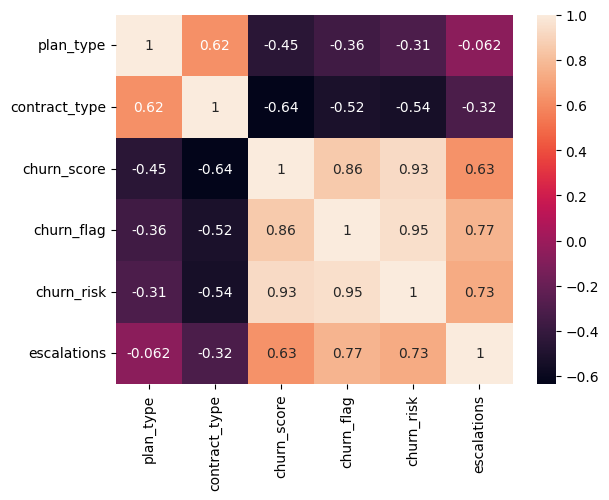

In [90]:
# encoding - convert str to numeric so that we can find corr between features

sns.heatmap(df_encoded.corr(),annot=True)

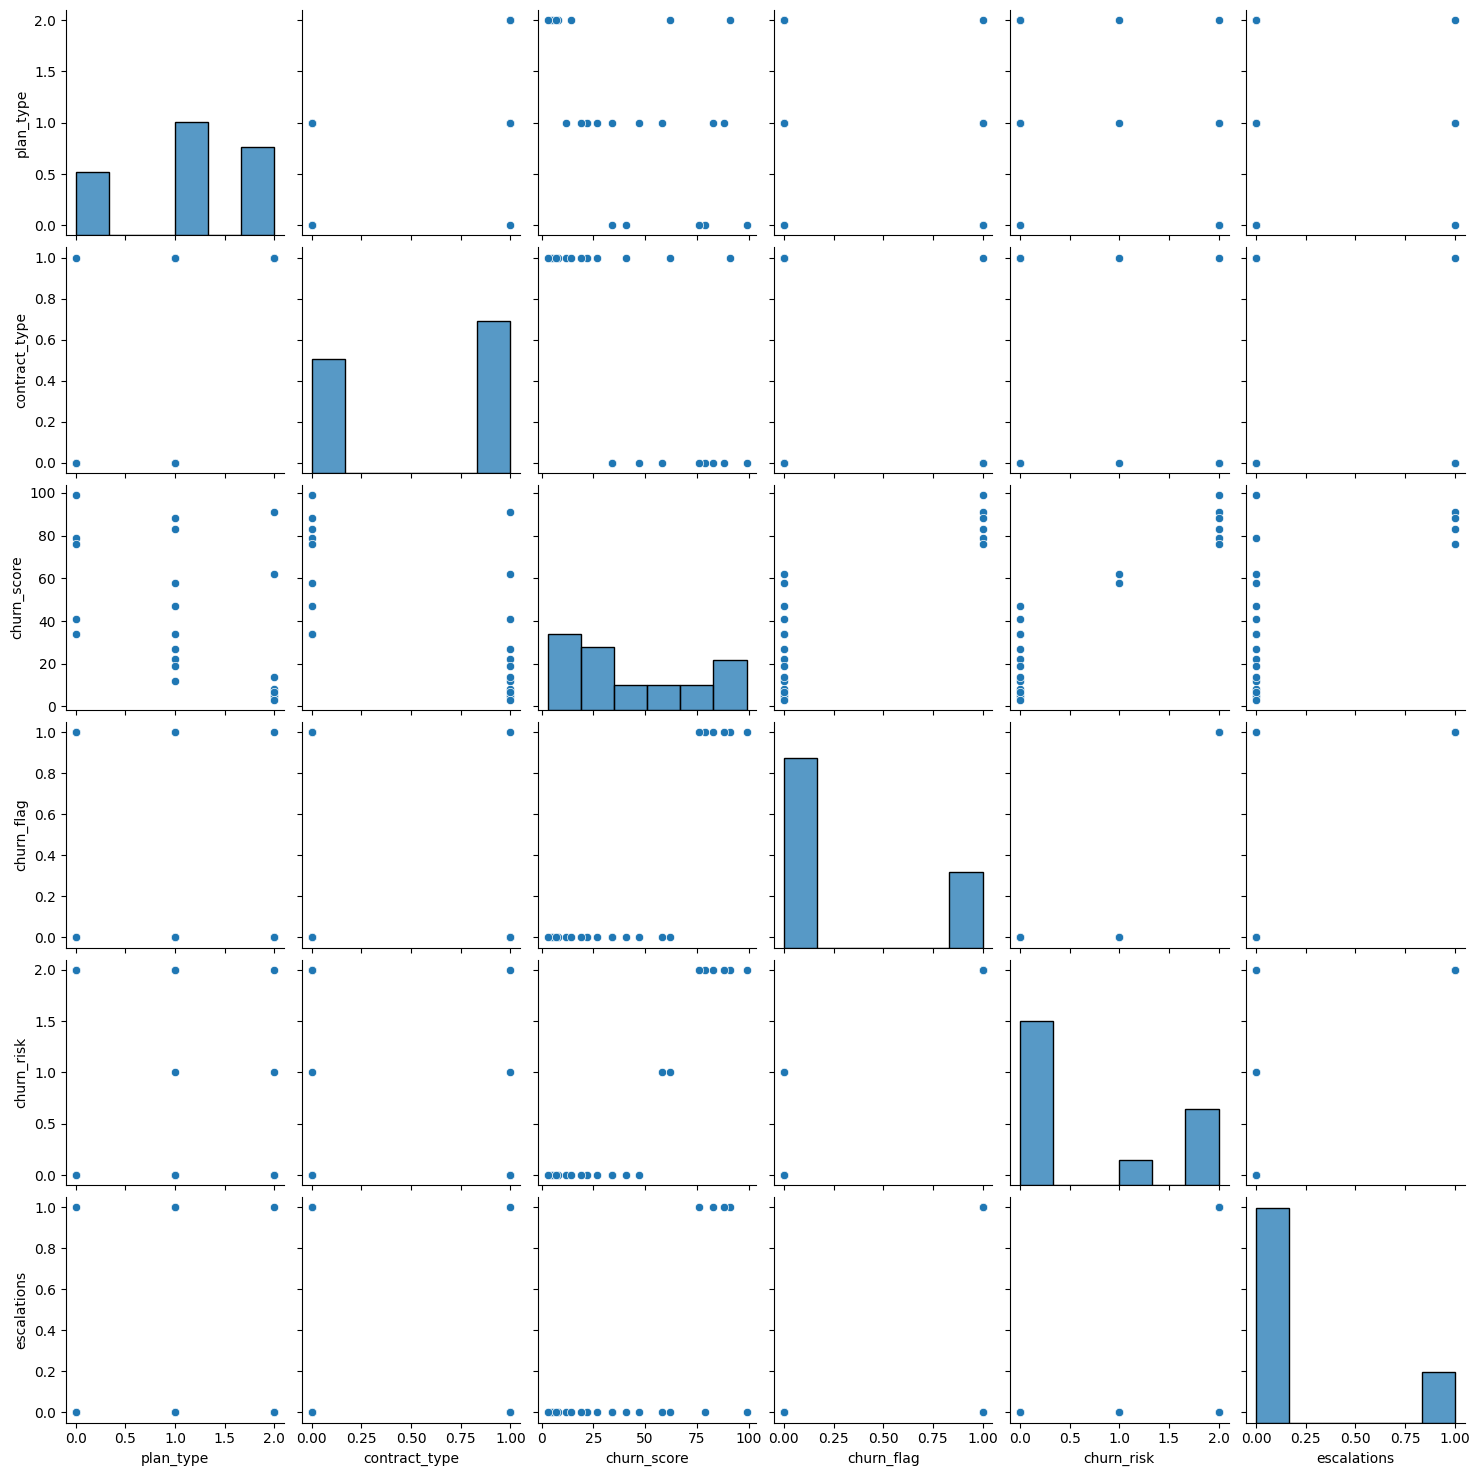

In [91]:
sns.pairplot(df_encoded)

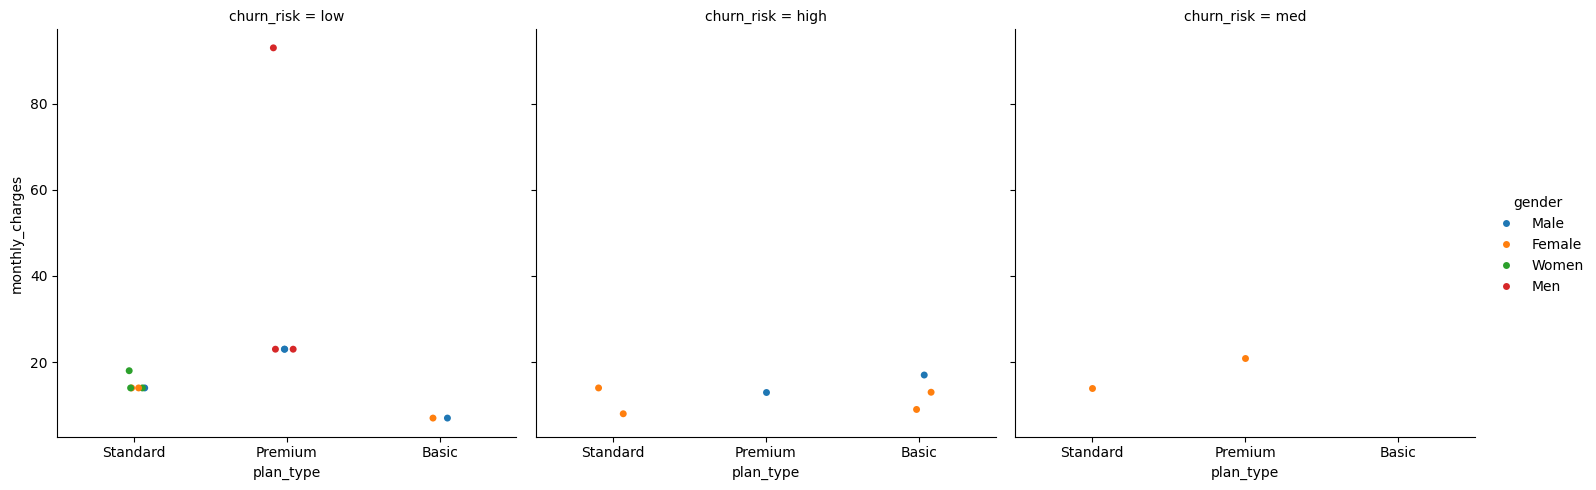

In [93]:
sns.catplot(data = df_visual,
           x = 'plan_type',
           y = 'monthly_charges', 
           hue = 'gender', 
           col = 'churn_risk')

# Pivot Table

In [95]:
pd.pivot_table(
    df_visual, 
    values='churn_flag', 
    index = 'plan_type',
    aggfunc= 'mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [98]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk'],
      dtype='object')

In [99]:
pd.pivot_table(
    df_visual, 
    values=['monthly_charges','customerid','churn_flag'], 
    index = 'plan_type',
    aggfunc= {'monthly_charges' : 'sum',
              'customerid' : 'nunique', 
              'churn_flag' : 'mean'}
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
